In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")

ip_df = pd.read_csv(
    "../data/raw/IpAddress_to_Country.csv"
)

fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [15]:
fraud_df["signup_time"] = pd.to_datetime(
    fraud_df["signup_time"]
)

fraud_df["purchase_time"] = pd.to_datetime(
    fraud_df["purchase_time"]
)

In [16]:
ip_df.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [17]:
fraud_df["ip_address"].dtype

dtype('float64')

In [18]:
ip_df.dtypes

lower_bound_ip_address    float64
upper_bound_ip_address      int64
country                       str
dtype: object

In [19]:
fraud_df["ip_address"] = fraud_df["ip_address"].astype(np.int64)

ip_df["lower_bound_ip_address"] = (
    ip_df["lower_bound_ip_address"]
    .astype(np.int64)
)

ip_df["upper_bound_ip_address"] = (
    ip_df["upper_bound_ip_address"]
    .astype(np.int64)
)

In [20]:
ip_df = ip_df.sort_values(
    by="lower_bound_ip_address"
)

In [21]:
fraud_df = pd.merge_asof(
    fraud_df.sort_values("ip_address"),
    ip_df,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

In [22]:
fraud_df = fraud_df[
    fraud_df["ip_address"]
    <= fraud_df["upper_bound_ip_address"]
]

In [23]:
fraud_df = fraud_df[
    fraud_df["ip_address"]
    <= fraud_df["upper_bound_ip_address"]
]

In [24]:
fraud_df["country"].value_counts().head(20)

country
United States                      58049
China                              12038
Japan                               7306
United Kingdom                      4490
Korea Republic of                   4162
Germany                             3646
France                              3161
Canada                              2975
Brazil                              2961
Italy                               1944
Australia                           1844
Netherlands                         1680
Russian Federation                  1616
India                               1310
Taiwan; Republic of China (ROC)     1237
Mexico                              1121
Sweden                              1090
Spain                               1027
South Africa                         838
Switzerland                          785
Name: count, dtype: int64

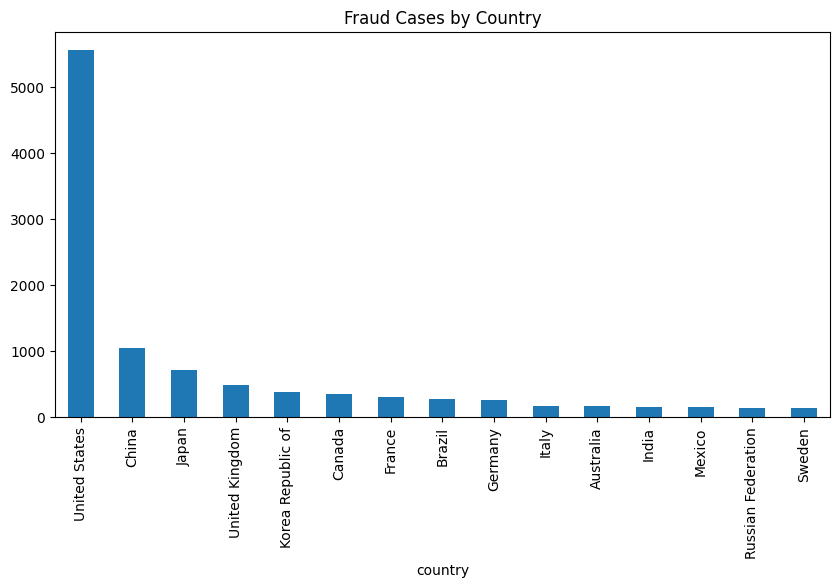

In [25]:
top_country_fraud = (
    fraud_df[fraud_df["class"] == 1]
    ["country"]
    .value_counts()
    .head(15)
)

top_country_fraud.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Fraud Cases by Country")
plt.show()

In [26]:
country_fraud_rate = (
    fraud_df.groupby("country")["class"]
    .mean()
    .sort_values(ascending=False)
)

country_fraud_rate.head(15)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Ireland                  0.229167
New Zealand              0.223022
Uzbekistan               0.200000
Lithuania                0.189474
Saudi Arabia             0.189394
Name: class, dtype: float64

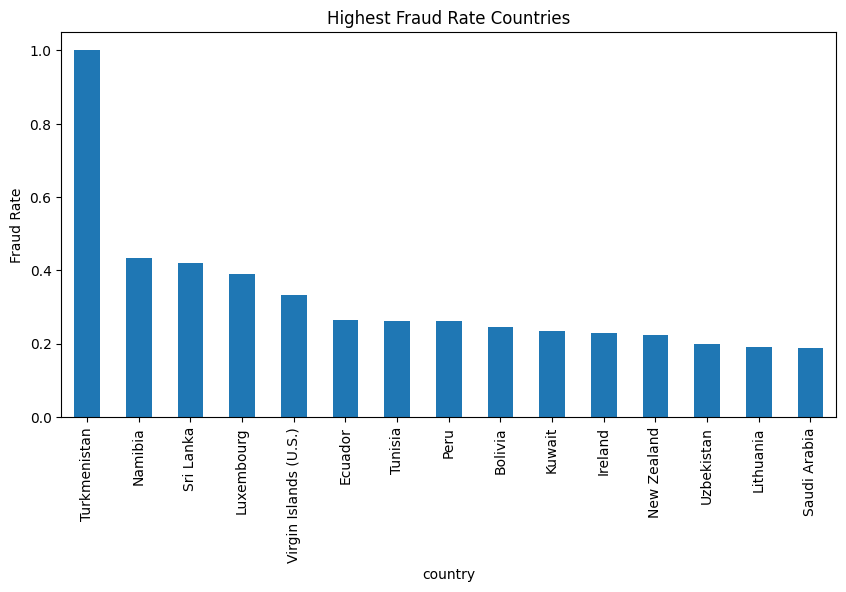

In [27]:
country_fraud_rate.head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Highest Fraud Rate Countries")
plt.ylabel("Fraud Rate")
plt.show()

In [28]:
fraud_df["time_since_signup"] = (
    fraud_df["purchase_time"]
    - fraud_df["signup_time"]
).dt.total_seconds()

In [29]:
fraud_df["hour_of_day"] = (
    fraud_df["purchase_time"].dt.hour
)

In [30]:
fraud_df["day_of_week"] = (
    fraud_df["purchase_time"].dt.dayofweek
)

In [31]:
user_tx_count = (
    fraud_df.groupby("user_id")
    .size()
)

fraud_df["transaction_count"] = (
    fraud_df["user_id"]
    .map(user_tx_count)
)

In [32]:
fraud_df = fraud_df.sort_values(
    ["user_id", "purchase_time"]
)

fraud_df["time_since_previous_tx"] = (
    fraud_df.groupby("user_id")
    ["purchase_time"]
    .diff()
    .dt.total_seconds()
)

In [33]:
fraud_df[
    [
        "time_since_signup",
        "hour_of_day",
        "day_of_week",
        "transaction_count",
        "time_since_previous_tx"
    ]
].head()

,time_since_signup,hour_of_day,day_of_week,transaction_count,time_since_previous_tx
31545,3564984.0,10,5,1,NaN
97542,10039879.0,21,5,1,NaN
12873,6667201.0,11,3,1,NaN
104500,4631485.0,20,2,1,NaN
21011,3193080.0,12,3,1,NaN


In [34]:
fraud_df.columns.tolist()

['user_id',
 'signup_time',
 'purchase_time',
 'purchase_value',
 'device_id',
 'source',
 'browser',
 'sex',
 'age',
 'ip_address',
 'class',
 'lower_bound_ip_address',
 'upper_bound_ip_address',
 'country',
 'time_since_signup',
 'hour_of_day',
 'day_of_week',
 'transaction_count',
 'time_since_previous_tx']

In [35]:
fraud_df_model = fraud_df.drop(
    columns=[
        "signup_time",
        "purchase_time"
    ]
)

In [36]:
fraud_df_model = fraud_df_model.drop(
    columns=[
        "user_id",
        "device_id"
    ]
)

In [37]:
fraud_df_model[
    "time_since_previous_tx"
] = fraud_df_model[
    "time_since_previous_tx"
].fillna(0)

In [38]:
fraud_encoded = pd.get_dummies(
    fraud_df_model,
    columns=[
        "source",
        "browser",
        "sex",
        "country"
    ],
    drop_first=True
)

In [39]:
fraud_encoded.head()

,purchase_value,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,time_since_signup,hour_of_day,day_of_week,transaction_count,...,country_United States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
31545,54,25,880217484,0,8.724152e+08,8.891924e+08,3564984.0,10,5,1,...,True,False,False,False,False,False,False,False,False,False
97542,41,38,2785906106,0,2.785542e+09,2.786066e+09,10039879.0,21,5,1,...,False,False,False,False,False,False,False,False,False,False
12873,47,25,356056736,0,3.523215e+08,3.690988e+08,6667201.0,11,3,1,...,True,False,False,False,False,False,False,False,False,False
104500,35,19,2985180352,0,2.985034e+09,2.985296e+09,4631485.0,20,2,1,...,False,False,False,False,False,False,False,False,False,False
21011,9,32,578312545,0,5.704253e+08,5.872026e+08,3193080.0,12,3,1,...,True,False,False,False,False,False,False,False,False,False


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [41]:
X = fraud_encoded.drop(
    columns=["class"]
)

y = fraud_encoded["class"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

In [45]:
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [46]:
print(y_train.value_counts())

print(
    y_train.value_counts(normalize=True) * 100
)

class
0    93502
1     9814
Name: count, dtype: int64
class
0    90.500987
1     9.499013
Name: proportion, dtype: float64


In [48]:
smote = SMOTE(
    random_state=42
)

X_train_resampled, y_train_resampled = (
    smote.fit_resample(
        X_train,
        y_train
    )
)

In [49]:
print(
    y_train_resampled.value_counts()
)

class
0    93502
1    93502
Name: count, dtype: int64


In [50]:
print(
    y_train_resampled.value_counts(
        normalize=True
    ) * 100
)

class
0    50.0
1    50.0
Name: proportion, dtype: float64


In [51]:
fraud_encoded.to_csv(
    "../data/processed/fraud_processed.csv",
    index=False
)

In [52]:
pd.DataFrame(X_train_resampled).to_csv(
    "../data/processed/X_train_smote.csv",
    index=False
)

pd.DataFrame(y_train_resampled).to_csv(
    "../data/processed/y_train_smote.csv",
    index=False
)